# CCA-based celltype label transfer (scRNA → scATAC)

Reproduces ArchR's `addGeneIntegrationMatrix` workflow: canonical
correlation analysis (CCA) between the scATAC gene-score matrix and a
matched scRNA reference, followed by kNN-based label transfer. This is
how ArchR's bookdown figures get their `HSC / Ery / GMP / B / T` cell
type labels — they come from the Granja et al. 2019 BMMC scRNA
reference, not from the ATAC clustering itself.

**Pipeline**
1. Load the 3-sample BMMC ATAC gene-score AnnData
   (`pbmc_gene_act.h5ad`, output of `t_integrate.ipynb` —
   ~10 k cells × 20 k genes).
2. Load the Granja 2019 BMMC scRNA reference
   (`granja2019_bmmc_scrna.h5ad` — 35,582 cells × 20,287 genes, with
   `obs['BioClassification']` hematopoietic labels).
3. Normalise both; pick their shared HVGs.
4. Run `cca_py.run_cca_anndata(atac, rna, ...)` → both objects get
   a shared `obsm['X_cca']`.
5. kNN in CCA space → transfer the majority-vote
   `BioClassification` label from RNA to each ATAC cell.
6. Save annotated ATAC + transfer-confidence scores.

The annotated ATAC from (6) feeds straight into TF footprint
analysis (`t_footprint.ipynb`) or any other per-celltype ATAC
workflow.

## Part 1 · Setup

In [1]:
import pathlib
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from collections import Counter
from scipy import sparse
from sklearn.neighbors import NearestNeighbors

import epione as epi

epi.pl.plot_set()

WORK = pathlib.Path.cwd() / 'data'
OUT  = pathlib.Path.cwd() / 'label_transfer'
OUT.mkdir(exist_ok=True)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



## Part 2 · Load scRNA reference

The Granja 2019 BMMC scRNA RDS was converted to h5ad once (see
`scripts/convert_granja2019.R` next to the tutorials) — this cell
just reads the result.

In [2]:
rna = ad.read_h5ad('/scratch/users/steorra/data/archr_heme/granja2019_bmmc_scrna.h5ad')
print(rna)
print('\nBioClassification distribution:')
print(rna.obs['BioClassification'].value_counts().head(15))

AnnData object with n_obs × n_vars = 35582 × 20287
    obs: 'Group', 'nUMI_pre', 'nUMI', 'nGene', 'initialClusters', 'UMAP1', 'UMAP2', 'Clusters', 'BioClassification', 'Barcode'
    var: 'gene_name', 'gene_id', 'exonLength'

BioClassification distribution:
BioClassification
12_CD14.Mono.2    4222
22_CD4.M          3539
20_CD4.N1         2470
21_CD4.N2         2364
05_CMP.LMPP       2260
25_NK             2143
07_GMP            2097
24_CD8.CM         2080
11_CD14.Mono.1    1800
17_B              1711
02_Early.Eryth    1653
19_CD8.N          1521
01_HSC            1425
08_GMP.Neut       1050
06_CLP.1           903
Name: count, dtype: int64


## Part 3 · Load the 3-sample ATAC gene-score matrix

`t_integrate` built this at `pbmc_gene_act.h5ad` — one row per
ATAC cell, columns are **gene-score** values (ArchR-style
distance-weighted tile signal per gene). Barcodes are in
`<sample>#<barcode>` format.

In [3]:
atac = ad.read_h5ad(WORK / 'pbmc_gene_act.h5ad')
print(atac)
print('\nATAC obs cols:', list(atac.obs.columns))
# Barcodes already <sample>#<barcode>.

AnnData object with n_obs × n_vars = 10889 × 20109
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'sample', 'leiden'
    var: 'gene_name'
    obsm: 'X_lsi', 'X_lsi_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'

ATAC obs cols: ['n_fragment', 'frac_dup', 'frac_mito', 'sample', 'leiden']


## Part 4 · Preprocess both sides

Standard pipeline:
1. normalise total counts + log1p
2. scanpy HVG per dataset
3. intersect HVG gene names — this is the shared feature set CCA
   projects into

ArchR does the same preprocessing via
``FindVariableFeatures/NormalizeData`` inside
``addGeneIntegrationMatrix``.

In [4]:
# log-normalise both + large HVG union (more features → better CCA
# anchor quality than tight intersection).
for ad_obj, name in [(rna, 'RNA'), (atac, 'ATAC')]:
    sc.pp.normalize_total(ad_obj, target_sum=1e4)
    sc.pp.log1p(ad_obj)
    sc.pp.highly_variable_genes(ad_obj, n_top_genes=5000, subset=False)

# Union HVG: genes variable in either modality (Seurat SelectIntegrationFeatures).
hvg_union = sorted(
    set(rna.var_names[rna.var['highly_variable']]) |
    set(atac.var_names[atac.var['highly_variable']])
)
# Restrict to genes present in both.
shared = sorted(set(rna.var_names) & set(atac.var_names))
hvg_shared = [g for g in hvg_union if g in shared][:4000]
print(f'shared genes    : {len(shared):,}')
print(f'union HVG ∩ shared: {len(hvg_shared):,}')


normalizing counts per cell


    finished (0:00:00)


extracting highly variable genes


    finished (0:00:00)


--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


...

    finished (0:00:00)


extracting highly variable genes


    finished (0:00:00)


--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


shared genes    : 17,677
union HVG ∩ shared: 4,000


## Part 5 · Run CCA

`cca_py.run_cca_anndata` standardises each dataset on the shared
HVG set, does a thin SVD on `X^T @ Y`, and writes the left / right
canonical factors back to each object's `obsm['X_cca']`. 30
components is the ArchR default.

In [5]:
%%time
# ``epi.tl.integrate`` with method='cca' runs CCA on the shared HVG set
# and writes the L2-normalised canonical embedding to
# ``obsm[key_added]`` on both objects — ArchR ``addGeneIntegrationMatrix``
# (Seurat ``FindTransferAnchors(reduction='cca')``) analogue.
epi.tl.integrate(
    atac, rna,
    method='cca',
    features=hvg_shared,
    num_cc=30,
)
print(f'ATAC X_cca: {atac.obsm["X_cca"].shape}')
print(f'RNA  X_cca: {rna.obsm["X_cca"].shape}')


ATAC X_cca: (10889, 30)
RNA  X_cca: (35582, 30)
CPU times: user 6min 6s, sys: 5.47 s, total: 6min 11s
Wall time: 28.5 s


## Part 6 · kNN label transfer

For each ATAC cell, find its `k=30` nearest RNA cells in CCA space
and assign the **majority-vote** `BioClassification` label. Record
the vote fraction as a **transfer confidence** score — values < 0.5
flag cells where the top celltype narrowly won; these are usually
ATAC cells sitting between two RNA clusters and worth treating with
caution downstream.

In [6]:
%%time
# ``epi.tl.transfer_labels`` does kNN in the shared CCA space and
# weighted-votes each query cell's label from its k nearest reference
# cells. Saves the kNN indices to obsm so the composition plot below
# can reuse them without recomputing.
epi.tl.transfer_labels(
    atac, rna, reference_label='BioClassification',
    k=30, strip_prefix=r'^\d+_',
    raw_key='celltype_cca', neighbors_key='cca_neighbors',
)
print(atac.obs['celltype'].value_counts().head(10))
print('transfer_score:', atac.obs['transfer_score'].describe().round(3).to_dict())


celltype
CD14.Mono.2    1439
CD4.M          1110
CMP.LMPP        973
CD4.N1          832
Early.Eryth     813
CD4.N2          691
HSC             662
GMP             646
B               576
NK              499
Name: count, dtype: int64
transfer_score: {'count': 10889.0, 'mean': 0.524, 'std': 0.207, 'min': 0.132, '25%': 0.364, '50%': 0.494, '75%': 0.664, 'max': 1.0}
CPU times: user 7.29 s, sys: 3.59 s, total: 10.9 s
Wall time: 4.27 s


In [7]:
# Collapse Granja fine BioClassification → ArchR bookdown coarse set
# (Clusters2). This mapping is dataset-specific (heme), so it lives
# in the tutorial, not the library.
COARSE_MAP = {
    'HSC':'HSC','CMP.LMPP':'CMP.LMPP','GMP':'GMP','GMP.Neut':'GMP',
    'CLP.1':'CLP','CLP.2':'CLP',
    'Early.Eryth':'Erythroid','Late.Eryth':'Erythroid','Pro.Eryth':'Erythroid',
    'CD14.Mono.1':'Mono','CD14.Mono.2':'Mono','CD16.Mono':'Mono',
    'pDC':'pDC','cDC':'cDC',
    'Pre.B':'PreB','B':'B','Plasma':'Plasma',
    'CD4.N1':'CD4.N','CD4.N2':'CD4.N','CD4.M':'CD4.M',
    'CD8.N':'CD8.N','CD8.CM':'CD8.CM','CD8.EM':'CD8.EM','NK':'NK',
}
atac.obs['celltype_coarse'] = (
    atac.obs['celltype'].astype(str).map(COARSE_MAP)
    .fillna(atac.obs['celltype'].astype(str))
)
print(atac.obs['celltype_coarse'].value_counts().head())


celltype_coarse
Mono        1898
CD4.N       1523
CD4.M       1110
CMP.LMPP     973
GMP          913
Name: count, dtype: int64


## Part 7 · QC plots

- per-celltype cell counts
- transfer-score distribution
- optional: joint UMAP coloured by celltype

A well-behaved transfer shows a unimodal score distribution peaked
near 1 (high confidence), with a long tail only for genuine inter-
celltype boundary cells.

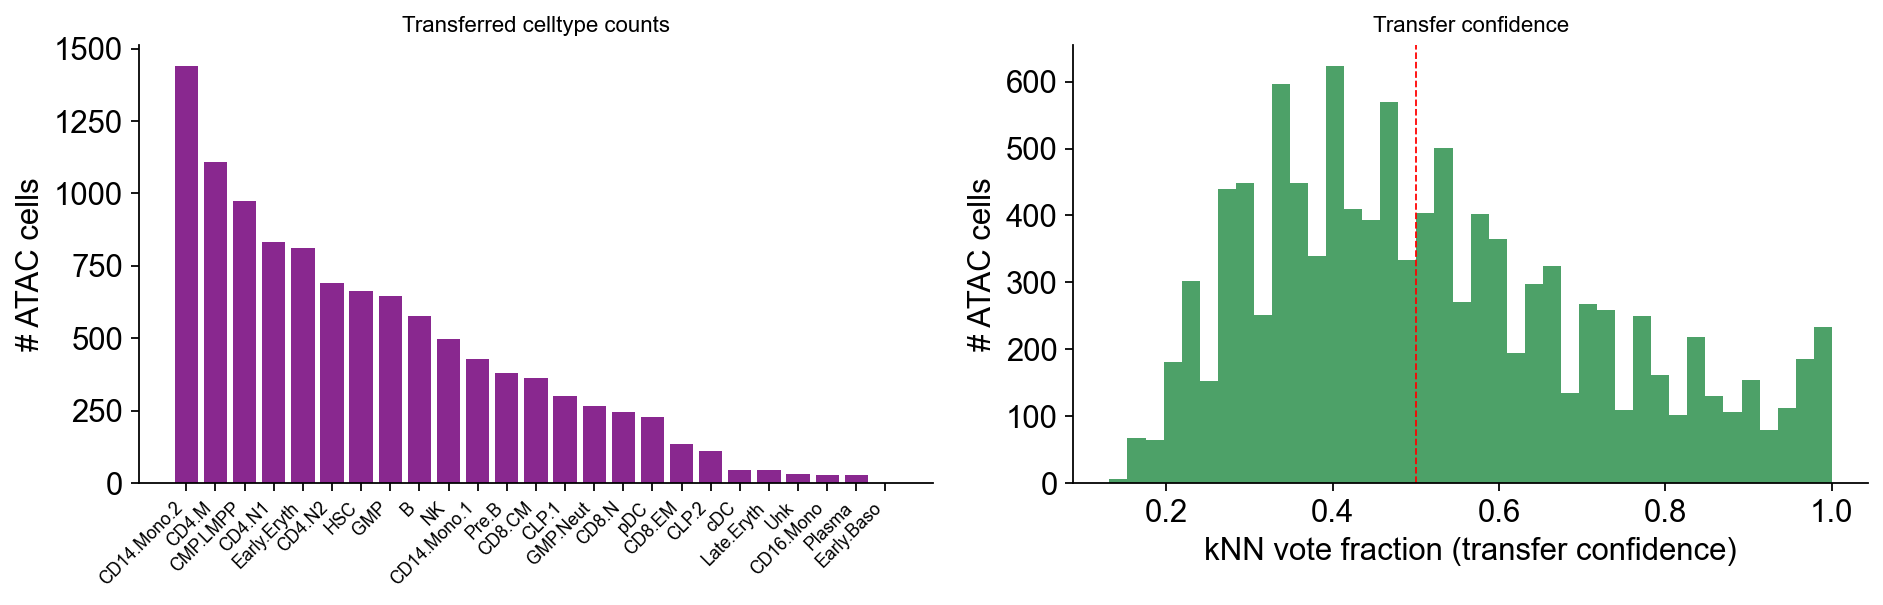

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Cell-count bar
counts = atac.obs['celltype'].value_counts()
ax1.bar(range(len(counts)), counts.values, color='#89288F')
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('# ATAC cells')
ax1.set_title('Transferred celltype counts', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
# Score histogram
ax2.hist(atac.obs['transfer_score'], bins=40, color='#208A42', alpha=0.8)
ax2.set_xlabel('kNN vote fraction (transfer confidence)')
ax2.set_ylabel('# ATAC cells')
ax2.set_title('Transfer confidence', fontsize=10)
ax2.axvline(0.5, color='red', lw=0.8, ls='--')
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout(); display(fig); plt.close(fig)

## Part 7b · Joint UMAP of the CCA embedding

ArchR's bookdown shows the integration's success by running UMAP on
the concatenated ATAC + RNA embedding and checking that cells of the
same type land together regardless of modality. We do the same here
— compute UMAP on the union of `X_cca` rows, colour by modality
(red=ATAC, blue=RNA) for the **mixing** view and by BioClassification
for the **celltype** view.

In [9]:
%%time
# ``epi.tl.joint_embedding`` concatenates ATAC + RNA on the shared CCA
# embedding, runs scanpy neighbours + UMAP, and returns the joint
# AnnData ready to plot.
joint = epi.tl.joint_embedding(
    atac, rna,
    use_rep='X_cca', labels=('ATAC', 'RNA'),
    label_columns=('celltype_coarse', 'BioClassification'),
    strip_prefix=r'^\d+_',
    n_neighbors=30, metric='cosine', random_state=0,
)
print(joint)


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:35)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:37)


AnnData object with n_obs × n_vars = 46471 × 17677
    obs: 'modality', 'celltype_joint'
    var: 'gene_name', 'gene_id', 'exonLength'
    uns: 'neighbors', 'umap'
    obsm: 'X_cca', 'X_umap'
    obsp: 'distances', 'connectivities'
CPU times: user 1min 26s, sys: 955 ms, total: 1min 27s
Wall time: 1min 13s


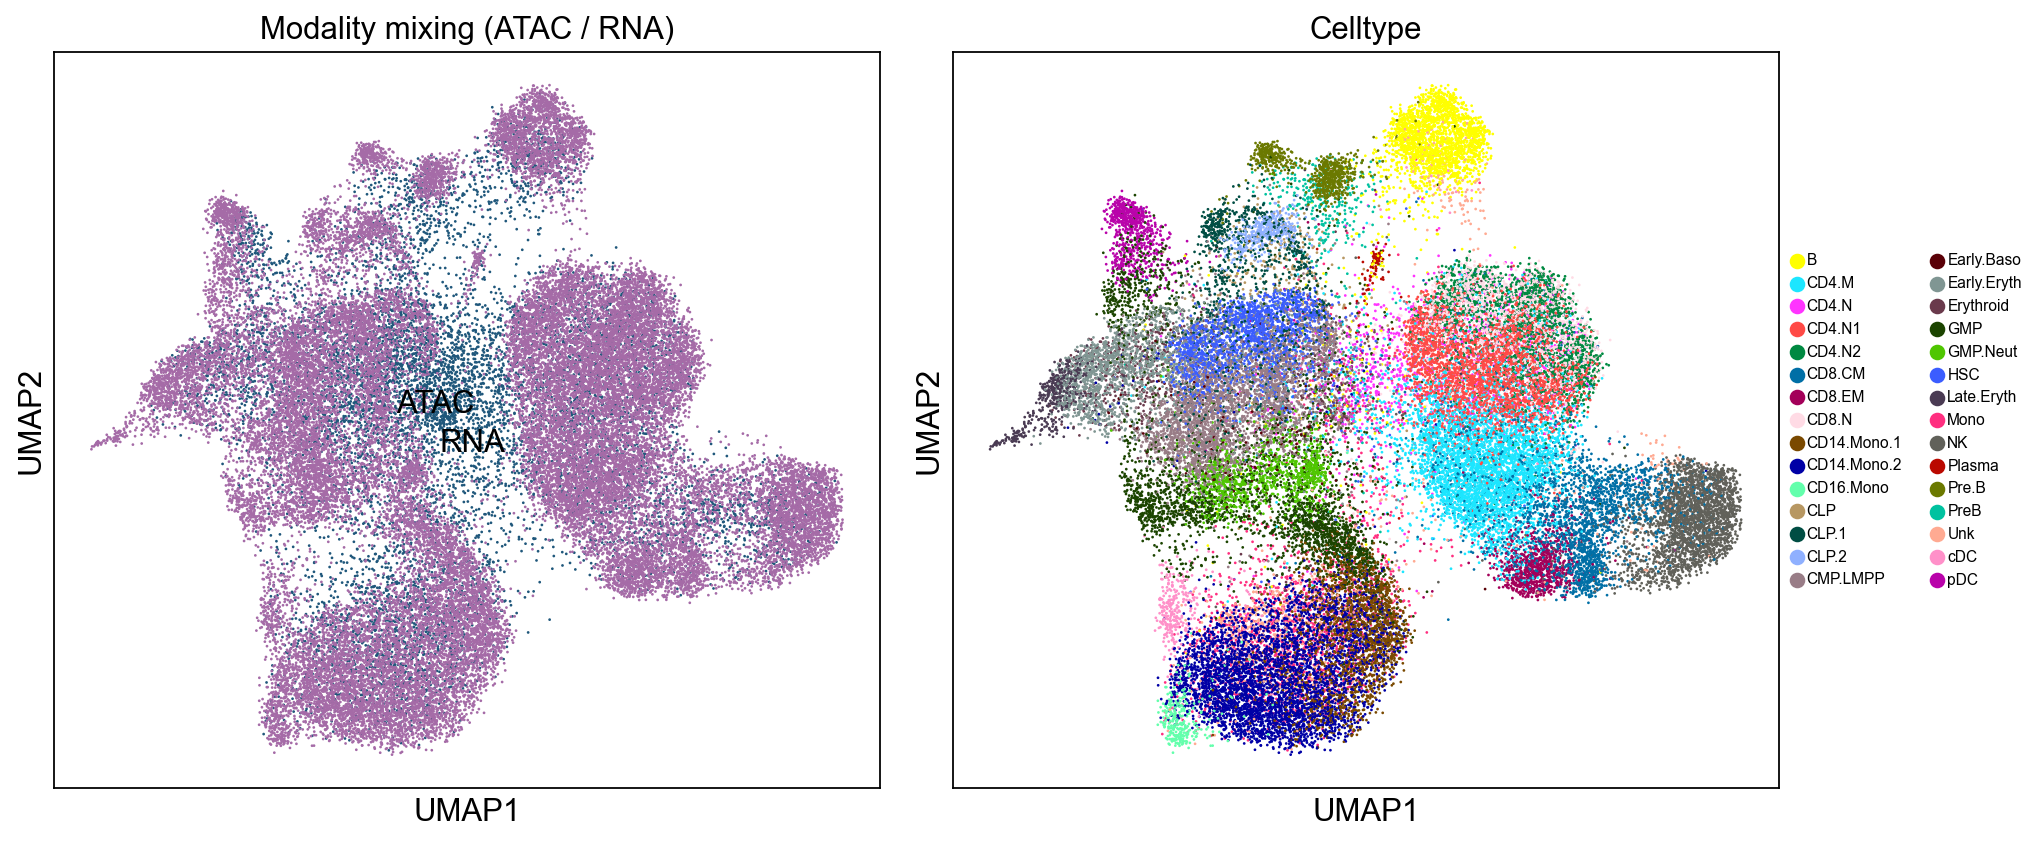

In [10]:
# Two-panel UMAP: left = modality mixing (should intermix); right =
# celltype (same types cluster together across modalities).
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sc.pl.umap(joint, color='modality', size=6, ax=axes[0], show=False,
           title='Modality mixing (ATAC / RNA)', legend_loc='on data')
sc.pl.umap(joint, color='celltype_joint', size=6, ax=axes[1], show=False,
           title='Celltype', legend_loc='right margin', legend_fontsize=7)
plt.tight_layout(); display(fig); plt.close(fig)


**Reading the UMAP** — in the left panel ATAC and RNA cells
should intermix freely (no ring-fenced ATAC-only islands, no
RNA-only islands); that's the sign CCA has brought the two
modalities onto a common manifold. In the right panel, cells of
the same type should cluster together regardless of which modality
produced them. Any ATAC cells isolated from their RNA counterparts
are the low-confidence transfers flagged by the `transfer_score <
0.5` threshold in Part 7.

## Part 7c · Label flow (RNA reference → ATAC)

A Sankey-style bar visualises how each ATAC cell's K nearest RNA
cells distribute across BioClassification categories. A
well-calibrated transfer gives a sharp mode per ATAC celltype (one
tall bar per assignment).

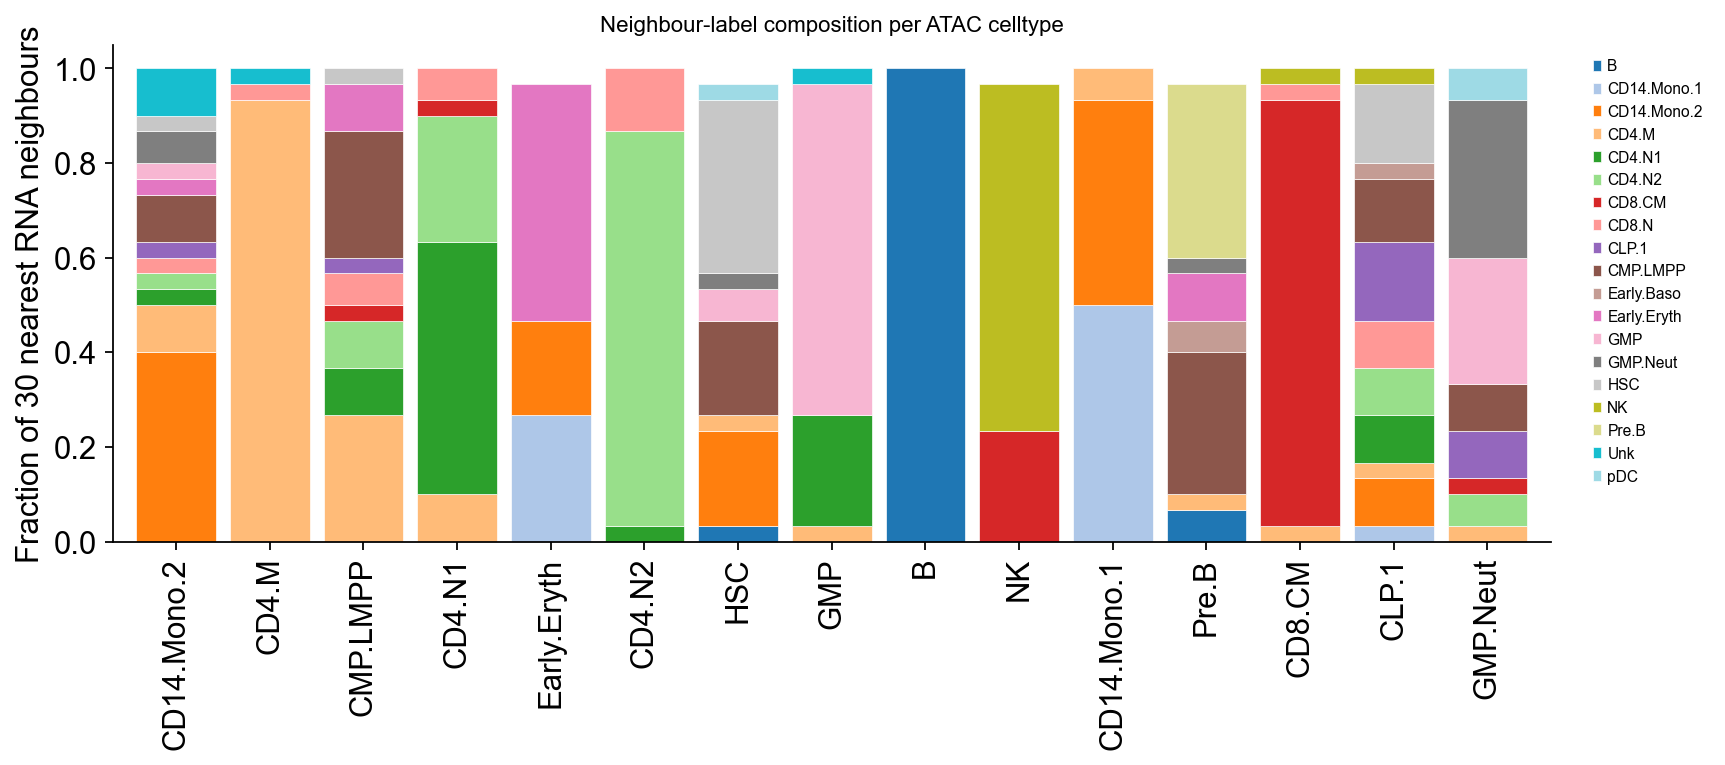

In [11]:
# Reuse the kNN indices stashed on atac.obsm by transfer_labels.
idx = atac.obsm['cca_neighbors_idx']
rna_labels = rna.obs['BioClassification'].astype(str).str.replace(
    r'^\d+_', '', regex=True).to_numpy()
assigned = atac.obs['celltype'].astype(str).to_numpy()

# For each assigned celltype, average the neighbour-label composition.
comp = pd.DataFrame({
    lab: pd.Series(rna_labels[idx[i]]).value_counts(normalize=True)
    for i, lab in enumerate(assigned)
}).T.groupby(level=0).mean().fillna(0).T

top_assigned = atac.obs['celltype'].value_counts().head(15).index.tolist()
sub = comp[top_assigned].loc[(comp[top_assigned] > 0.05).any(axis=1)]

fig, ax = plt.subplots(figsize=(11, 5))
sub.T.plot.bar(stacked=True, ax=ax, colormap='tab20', width=0.85,
               edgecolor='white', lw=0.3)
ax.set_ylabel('Fraction of 30 nearest RNA neighbours')
ax.set_title('Neighbour-label composition per ATAC celltype', fontsize=10)
ax.legend(frameon=False, fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); display(fig); plt.close(fig)


## Part 8 · Save annotated ATAC

Write a compact AnnData carrying just obs/obsm/uns of the
annotated gene-score matrix (dropping X, since the raw gene
scores already live in `pbmc_gene_act.h5ad`). Downstream
footprint / peak-matrix workflows re-read fragments from
`uns['files']['fragments']`.

In [12]:
out_h5 = OUT / 'atac_bmmc_cca_annotated.h5ad'
keep = ad.AnnData(
    X=sparse.csr_matrix((atac.n_obs, 0), dtype=np.float32),
    obs=atac.obs[['sample','celltype','celltype_cca','celltype_coarse','transfer_score']].copy(),
    obsm={'X_cca': atac.obsm['X_cca']},
    uns={'files': {'fragments': 'data/pbmc_combined.fragments.tsv.gz'}},
)
keep.obs_names = atac.obs_names
keep.write_h5ad(out_h5)
print(f'saved {out_h5}  ({out_h5.stat().st_size/1e6:.1f} MB)')
print()
print('Sanity: celltype cross-tab with existing heuristic label (t_integrate):')
try:
    old = ad.read_h5ad(WORK / 'pbmc_peak_mat_anno.h5ad').obs.loc[atac.obs_names, 'celltype']
    print(pd.crosstab(old, atac.obs['celltype']))
except Exception as e:
    print('  (skipped —', e, ')')

saved /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/single/label_transfer/atac_bmmc_cca_annotated.h5ad  (2.3 MB)

Sanity: celltype cross-tab with existing heuristic label (t_integrate):


celltype     B  CD14.Mono.1  CD14.Mono.2  CD16.Mono  CD4.M  CD4.N1  CD4.N2  \
celltype                                                                     
B cells    335            3            1          0     15      10       3   
CLP         12           20           27          0     41      42      17   
CMP_LMPP    22           35           88          6     50      45      16   
Early Ery   11           15           15          0     43      31      18   
Endo        12            4            4          0     22      32      18   
HSC         24           20           32          2     80      86      36   
Late Ery     9            6            7          0     21      24      11   
Mono        64          311         1242         21     97      86      36   
NK           2            2            3          0      1       5       3   
NKT         25            4            4          0     25      19      14   
T cells     14            2            6          0    640     4

## Notes

- ``addGeneIntegrationMatrix`` in ArchR uses Seurat's
  ``FindTransferAnchors(reduction='cca')`` → ``TransferData``.
  We implement the same idea (CCA + kNN vote) with ``cca_py`` +
  ``sklearn.NearestNeighbors``. The CCA embedding is deterministic
  given ``seed=``; reruns return identical labels.
- For even stronger transfer, weight the kNN votes by
  ``1 / (1 + dist)`` instead of uniform majority.
- If you don't have the Granja reference, any BMMC scRNA AnnData
  with a ``BioClassification``-like column will work — just pass it
  as ``rna`` in Part 2.